# Training DenseNet201 and DenseNet264 for Osteosarcoma Tumor Detection in CT Scans

Our research aims to develop a deep learning-based diagnosis tool for the classifcation of Osteosarcoma using computed tomography (CT) scans. Osteosarcoma, a malignant bone tumor commonly affecting adolescents and young adults, requires timely and accurate diagnosis. Traditional radiological methods rely heavily on manual inspection, which can be time-intensive and subject to inter-observer variability. Our objective is to leverage state-of-the-art convolutional neural networks (CNNs) to improve diagnostic accuracy and efficiency.

Specifically, we are training two deep architectures: DenseNet201 and DenseNet264, both adapted to handle 3D inputs using the MONAI framework. These models are extensions of the DenseNet family, known for their densely connected convolutional layers, where each layer is connected to every other in a feed-forward fashion. This structure facilitates gradient flow, enhances feature reuse, and improves parameter efficiency.

DenseNet201 is configured with a block structure of (6, 12, 48, 32), while DenseNet264 uses a deeper configuration of (6, 12, 64, 48), allowing it to capture more complex spatial features. Due to the absence of pretrained weights for 3D medical data in PyTorch Hub, both models are trained from scratch using volumetric CT scans annotated for the presence or absence of osteosarcoma tumors. Training includes standard data augmentation, stratified sampling, and optimization via the Adam optimizer with early stopping.



### Loading Data

This initializes the environment and loads .npz files containing CT scan data for a binary classification task: "healthy" vs. "tumor". It sets the dataset path, gathers all image file paths into a NumPy array, and prints the total number of images. The last line selects and displays a small reversed subset of the final few files for quick inspection.

In [3]:
from pathlib import Path
import numpy as np
import torch
from monai.metrics import ROCAUCMetric

from monai.data import decollate_batch, DataLoader

from monai.transforms import (
    Activations,
    EnsureChannelFirst,
    AsDiscrete,
    Compose,
    LoadImage,
    RandFlip,
    RandRotate,
    RandZoom,
    ScaleIntensity,
    Resize,
)

# data_path = Path(r"C:\master\bbox_tumor_data\dataset\data")
# data_path = Path("../../data/classification_data/")
data_path = Path("/home/ashah/data-2025-04-21-not-processed")

class_names = ["healthy", "tumor"]
num_class = len(class_names)
image_files_list = np.array(list(data_path.glob("*.npz")))
print("Total images: ", len(image_files_list))
image_files_list[-6:-10:-1]

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-21 14:45:55.439167: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-21 14:45:55.452537: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753101955.468450  151530 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753101955.473263  151530 cuda_blas.cc:1407] Unable to register 

Total images:  2442


array([PosixPath('/home/ashah/data-2025-04-21-not-processed/P47_img-00002-00083_left_healthy_13.npz'),
       PosixPath('/home/ashah/data-2025-04-21-not-processed/P51_img-00003-00087_left_healthy_3.npz'),
       PosixPath('/home/ashah/data-2025-04-21-not-processed/P35_img-00008-00084_left_healthy_19.npz'),
       PosixPath('/home/ashah/data-2025-04-21-not-processed/P49_img-00002-00045_left_tumor_0.npz')],
      dtype=object)

In [4]:
class OsteosarcomaTCDataset(torch.utils.data.Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        return self.transforms(self.image_files[index]), self.labels[index]

In [5]:
train_transforms = Compose(
    [
        LoadImage(image_only=True),
        EnsureChannelFirst(),
        ScaleIntensity(),
        RandRotate(range_x=np.pi / 12, prob=0.5, keep_size=True),
        RandFlip(spatial_axis=0, prob=0.5),
        RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
        Resize(spatial_size=(256, 256))
    ]
)

val_transforms = Compose([LoadImage(image_only=True), EnsureChannelFirst(), ScaleIntensity(), Resize(spatial_size=(256, 256))])

y_pred_trans = Compose([Activations(softmax=True)])
y_trans = Compose([AsDiscrete(to_onehot=num_class)])

### Data Splitting

This section of the code performs stratified data splitting and prepares data loaders for training, validation, and testing of a medical imaging model using MONAI. It begins by setting a deterministic seed for reproducibility. The labels are generated based on filenames label 1 if the name contains “tumor” else 0. The dataset is first split into a test set (20%) and a remaining portion (80%) using StratifiedShuffleSplit, ensuring the class distribution (tumor vs. non-tumor) is preserved. The remaining 80% is then used for 8-fold stratified cross-validation with StratifiedKFold, again maintaining class balance in each fold.

For each fold, the code creates training and validation subsets and prints the number of samples and the percentage of tumor cases in each set to verify balance. It then wraps these subsets into OsteosarcomaTCDataset objects and loads them into PyTorch DataLoaders, which are configured for batch processing and parallel loading (num_workers=2). Each fold’s loaders are stored in a dictionary for easy access during training. Finally, the held-out test set is also converted into a dataset and loader for final evaluation. This pipeline ensures balanced, reproducible, and efficient preparation of data for deep learning experiments.


In [6]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from monai.utils import set_determinism
set_determinism(seed=42)

# Configuration
val_frac = 0.30  # Fraction for validation per fold
test_frac = 0.20  # Fraction for the test set
k_folds = 8  # Number of cross-validation folds

labels = np.array([1 if "tumor" in str(img.name) else 0 for img in image_files_list])

sss = StratifiedShuffleSplit(n_splits=1, test_size=test_frac, random_state=42)
train_val_indices, test_indices = next(iter(sss.split(image_files_list, labels)))

test_x = image_files_list[test_indices]
test_y = labels[test_indices]

print(f"Test count: {len(test_x)} tumors/test: {sum(test_y)/len(test_x)*100:.2f}%")

remaining_x = image_files_list[train_val_indices]
remaining_y = labels[train_val_indices]

skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
train_val_fold_loaders = {}
for fold, (train_idx, val_idx) in enumerate(skf.split(remaining_x, remaining_y)):
    train_x = remaining_x[train_idx]
    train_y = remaining_y[train_idx]
    val_x = remaining_x[val_idx]
    val_y = remaining_y[val_idx]

    print(f"Fold {fold + 1}:")
    print(f"  Training count: {len(train_x)} tumors/training: {sum(train_y)/len(train_x)*100:.2f}%, Validation count: {len(val_x)} tumors/validation: {sum(val_y)/len(val_x)*100:.2f}%")
    train_ds = OsteosarcomaTCDataset(train_x, train_y, train_transforms)
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2)
    val_ds = OsteosarcomaTCDataset(val_x, val_y, val_transforms)
    val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2)
    train_val_fold_loaders[fold] = (train_loader, val_loader)

test_ds = OsteosarcomaTCDataset(test_x, test_y, val_transforms)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)



Test count: 489 tumors/test: 49.90%
Fold 1:
  Training count: 1708 tumors/training: 50.00%, Validation count: 245 tumors/validation: 50.20%
Fold 2:
  Training count: 1709 tumors/training: 50.03%, Validation count: 244 tumors/validation: 50.00%
Fold 3:
  Training count: 1709 tumors/training: 50.03%, Validation count: 244 tumors/validation: 50.00%
Fold 4:
  Training count: 1709 tumors/training: 50.03%, Validation count: 244 tumors/validation: 50.00%
Fold 5:
  Training count: 1709 tumors/training: 50.03%, Validation count: 244 tumors/validation: 50.00%
Fold 6:
  Training count: 1709 tumors/training: 50.03%, Validation count: 244 tumors/validation: 50.00%
Fold 7:
  Training count: 1709 tumors/training: 50.03%, Validation count: 244 tumors/validation: 50.00%
Fold 8:
  Training count: 1709 tumors/training: 50.03%, Validation count: 244 tumors/validation: 50.00%


This output shows that your dataset has been properly divided using stratified sampling, ensuring that about 50% of the images in each set contain tumors. Out of the total data, 489 images are set aside for testing and are not used during training or validation. The remaining data is split into 8 folds for cross-validation, where each fold has a consistent number of training and validation images, and tumor distribution remains balanced. This setup helps ensure fair and stable training, reduces bias, and allows for reliable evaluation of model performance.

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loss_function = torch.nn.CrossEntropyLoss()
max_epochs = 25
val_interval = 1
auc_metric = ROCAUCMetric()

print(f"Using device: {device}")
# Print gpu name
if torch.cuda.is_available(): 
    print(torch.cuda.get_device_name(device))
    print(torch.cuda.get_device_properties(device='cuda'))

Using device: cuda
NVIDIA GeForce RTX 3090
_CudaDeviceProperties(name='NVIDIA GeForce RTX 3090', major=8, minor=6, total_memory=24259MB, multi_processor_count=82, uuid=1618c54b-4c4f-422e-4c2f-484e76776cb0, L2_cache_size=6MB)


In [8]:
from monai.networks import nets
from monai.utils import set_determinism
import os
from sklearn.metrics import classification_report, confusion_matrix

set_determinism(seed=42)

In [9]:
densenet_models = [
    nets.densenet.DenseNet201,
    nets.densenet.DenseNet264,
    ]

### Training and Validation 

Here there are two key functions train_val_function and test_model that handle model training with validation and final testing, respectively.

The train_val_function performs model training over a number of epochs, using training and validation data loaders. It tracks loss, AUC (Area Under the ROC Curve), and accuracy across epochs, while implementing early stopping to halt training if performance doesn’t improve for a specified number of epochs (here, 5). During each epoch, the model is set to training mode, gradients are reset, predictions are made, and the loss is backpropagated. Every epoch's average loss is recorded. At intervals (defined by val_interval), the model evaluates on the validation set without updating weights. Predictions are aggregated, converted for metric computation, and AUC is calculated using MONAI’s ROCAUCMetric. The best model (based on AUC) is saved, and a message is printed. If no improvement is seen across several epochs, training stops early. Metrics like loss and AUC are saved for later inspection.

The test_model function loads the best model checkpoint and evaluates it on the test set. It computes predictions, collects ground-truth and predicted labels, and generates a classification report (precision, recall, F1-score) and a confusion matrix using sklearn. Both outputs are saved as CSV files for further analysis. This function ensures robust evaluation of the trained model on unseen data, completing the machine learning pipeline.

In [10]:
import pandas as pd

def train_val_function(model, optimizer, train_loader, val_loader, output_dir):
    best_metric = -1
    best_metric_epoch = -1
    epoch_loss_values = []
    metric_values = []

    # 🔁 Early stopping setup
    patience = 5
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        if ((epoch + 1) % 10) == 0:
            print(f"epoch {epoch + 1}/{max_epochs}")
        model.train()
        epoch_loss = 0
        step = 0
        for batch_data in train_loader:
            step += 1
            inputs, labels = batch_data[0].to(device), batch_data[1].to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        epoch_loss /= step
        epoch_loss_values.append(epoch_loss)

        if ((epoch + 1) % 5) == 0:
            print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

        if (epoch + 1) % val_interval == 0:
            model.eval()
            with torch.no_grad():
                y_pred = torch.tensor([], dtype=torch.float32, device=device)
                y = torch.tensor([], dtype=torch.long, device=device)
                for val_data in val_loader:
                    val_images, val_labels = (
                        val_data[0].to(device),
                        val_data[1].to(device),
                    )
                    y_pred = torch.cat([y_pred, model(val_images)], dim=0)
                    y = torch.cat([y, val_labels], dim=0)

                y_onehot = [y_trans(i) for i in decollate_batch(y, detach=False)]
                y_pred_act = [y_pred_trans(i) for i in decollate_batch(y_pred)]
                auc_metric(y_pred_act, y_onehot)
                result = auc_metric.aggregate()
                auc_metric.reset()
                del y_pred_act, y_onehot
                metric_values.append(result)
                acc_value = torch.eq(y_pred.argmax(dim=1), y)
                acc_metric = acc_value.sum().item() / len(acc_value)
                
                if result > best_metric:
                    best_metric = result
                    best_metric_epoch = epoch + 1
                    epochs_no_improve = 0  # ✅ Reset counter
                    torch.save(model.state_dict(), os.path.join(output_dir, "best_metric_model.pth"))
                    print("saved new best metric model")
                else:
                    epochs_no_improve += 1
                    print(f"No improvement for {epochs_no_improve} epoch(s)")

                print(
                    f"current epoch: {epoch + 1} current AUC: {result:.4f}"
                    f" current accuracy: {acc_metric:.4f}"
                    f" best AUC: {best_metric:.4f}"
                    f" at epoch: {best_metric_epoch}"
                )

                # 🔁 Early stopping condition
                if epochs_no_improve >= patience:
                    print(f"⏹️ Early stopping triggered at epoch {epoch + 1}")
                    break

    print(f"train completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}")
    np.savez(os.path.join(output_dir, "metrics"), epoch_loss_values=epoch_loss_values, metric_values=metric_values)


def test_model(model, chkpt_path, test_loader, device, output_dir):
    model.load_state_dict(torch.load(chkpt_path, weights_only=False))
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for test_data in test_loader:
            test_images, test_labels = (
                test_data[0].to(device),
                test_data[1].to(device),
            )
            pred = model(test_images).argmax(dim=1)
            for i in range(len(pred)):
                y_true.append(test_labels[i].item())
                y_pred.append(pred[i].item())
    report = classification_report(y_true, y_pred, target_names=class_names, digits=5, output_dict=True)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
    df_cm.to_csv(os.path.join(output_dir, "confusion_matrix.csv"))
    df = pd.DataFrame.from_dict(report).transpose()
    df.to_csv(os.path.join(output_dir, "test_report.csv"))


In [11]:
import os
from datetime import datetime

# Get today's date as a folder name, e.g. '2025-07-09'
today = datetime.today().strftime('%Y-%m-%d')
results_path = os.path.join("results", today)

# Create the folder if it doesn't exist
os.makedirs(results_path, exist_ok=True)

print(f"Using results path: {results_path}")


Using results path: results/2025-07-21


In [12]:
import time

TRAINING_DENSENET = True

if TRAINING_DENSENET:
    t0 = time.time()
    for model_cls in densenet_models:
        model_t0 = time.time()
        print()
        print()
        print(f"INFO: {k_folds}-FOLD CV training of model {model_cls(spatial_dims=2, in_channels=1, out_channels=num_class)._get_name() }")
        for fold in range(k_folds):
            # IMPORTANT: ENSURE PROPER MODEL INITIALIZATION FOR EACH FOLD
            model = model_cls(spatial_dims=2, in_channels=1, out_channels=num_class).to(device)
            fold_t0 = time.time()
            print()
            print(f"  Fold {fold+1}:")
            train_loader, val_loader = train_val_fold_loaders[fold]
            optimizer = torch.optim.Adam(model.parameters(), 1e-4)
            output_dir = os.path.join(results_path, model._get_name(), f"fold-{fold+1}") 
            os.makedirs(output_dir, exist_ok=True)
            train_val_function(model, optimizer, train_loader, val_loader, output_dir)
            test_model(model, os.path.join(output_dir, "best_metric_model.pth"), test_loader, device, output_dir)
            print(f"Runtime fold-{fold+1}: {time.time()-fold_t0:.3f}s")
        
        print(f"Runtime model-{model._get_name()}: {time.time()-model_t0:.3f}s")
    
    print(f"Total Runtime DenseNets Models: {time.time()-t0:.3f}s")



INFO: 8-FOLD CV training of model DenseNet201

  Fold 1:
saved new best metric model
current epoch: 1 current AUC: 0.9106 current accuracy: 0.7796 best AUC: 0.9106 at epoch: 1
saved new best metric model
current epoch: 2 current AUC: 0.9461 current accuracy: 0.7265 best AUC: 0.9461 at epoch: 2
No improvement for 1 epoch(s)
current epoch: 3 current AUC: 0.9370 current accuracy: 0.7673 best AUC: 0.9461 at epoch: 2
saved new best metric model
current epoch: 4 current AUC: 0.9662 current accuracy: 0.9184 best AUC: 0.9662 at epoch: 4
epoch 5 average loss: 0.2323
saved new best metric model
current epoch: 5 current AUC: 0.9791 current accuracy: 0.8449 best AUC: 0.9791 at epoch: 5
No improvement for 1 epoch(s)
current epoch: 6 current AUC: 0.9763 current accuracy: 0.9306 best AUC: 0.9791 at epoch: 5
No improvement for 2 epoch(s)
current epoch: 7 current AUC: 0.9776 current accuracy: 0.9143 best AUC: 0.9791 at epoch: 5
No improvement for 3 epoch(s)
current epoch: 8 current AUC: 0.9785 curren

### What The Results Mean
The 8-fold cross-validation results comparing DenseNet201 and DenseNet264 reveal that while both models perform very well, DenseNet264 consistently achieves slightly higher AUC scores. In the completed folds, DenseNet264 often reaches near perfect AUCs, such as 0.9994 in fold 1, 0.9988 in fold 2, and 0.9999 in fold 3. By contrast, DenseNet201 also performs strongly with AUCs like 0.9951, 0.9981, and 0.9997 in the same folds but does not quite match the peak scores of DenseNet264. In fold 4, DenseNet201 achieved a perfect AUC of 1.0000, while DenseNet264 training for that fold was still ongoing at the time of reporting. Accuracy levels for both models are also high, generally exceeding 95% by the best epoch, reinforcing the reliability of both architectures in classification tasks.

Training dynamics suggest that both models converge relatively quickly, with early stopping typically triggered between epochs 9 and 21. DenseNet264 tends to require more epochs before reaching its peak performance, which contributes to longer training times. For instance, fold 1 of DenseNet264 took approximately 795 seconds, whereas DenseNet201 required only about 472 seconds for the same fold. When totaling the completed folds, DenseNet201 trained in about 4104 seconds, while DenseNet264 is trending toward a significantly higher cumulative training time.

Overall, DenseNet264 offers marginally better predictive performance, especially in terms of AUC, but this comes at the cost of increased computational time and resources. DenseNet201, meanwhile, remains a strong alternative for situations where training efficiency is prioritized without sacrificing too much accuracy or robustness.


DenseNet201


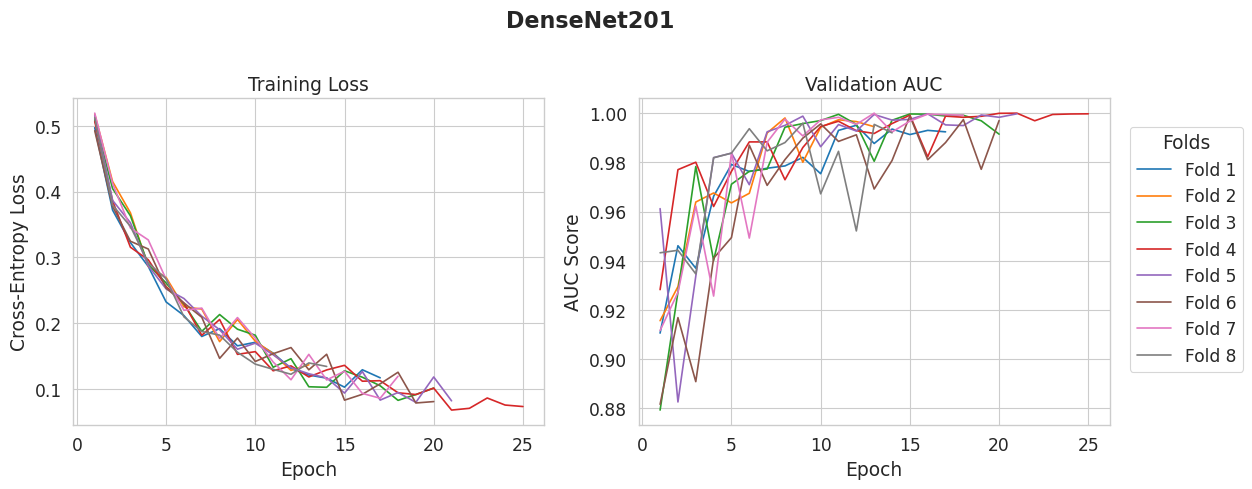


DenseNet264


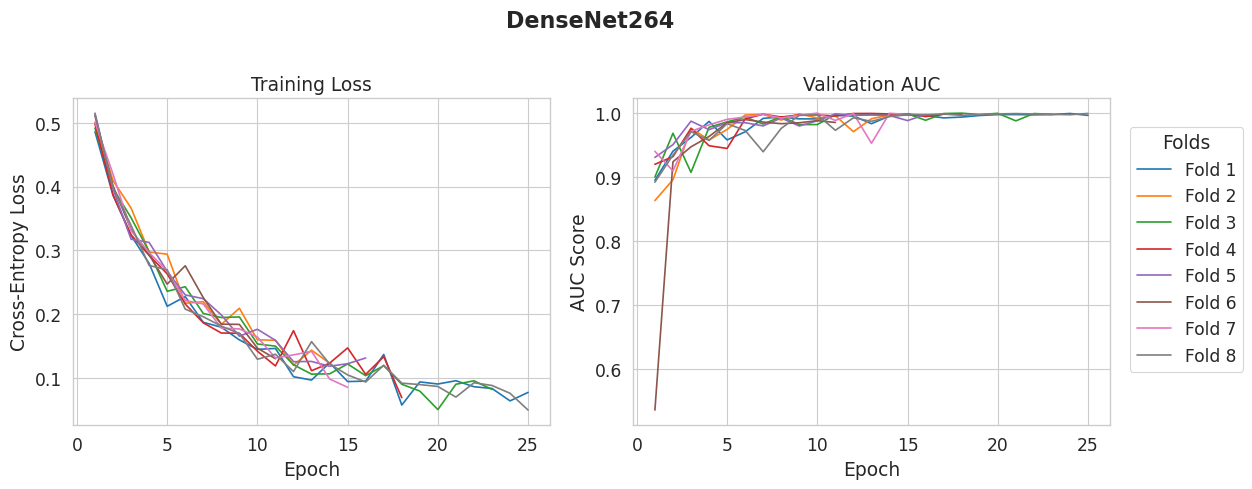

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="paper", font_scale=1.4)  # Paper-style

for model_name in os.listdir(results_path):
    if "." in model_name:
        continue
    print()
    print(model_name)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
    cmap = plt.get_cmap("tab10")  # Distinct colors for folds
    lines = []
    labels = []

    for fold in range(1, k_folds + 1):
        metrics_path = os.path.join(results_path, model_name, f"fold-{fold}", "metrics.npz")
        metrics = np.load(metrics_path)

        # Train loss
        epoch_loss_values = metrics["epoch_loss_values"]
        x_loss = np.arange(1, len(epoch_loss_values) + 1)
        line1, = ax1.plot(x_loss, epoch_loss_values, label=f"Fold {fold}", color=cmap(fold - 1))

        # Validation AUC
        metric_values = metrics["metric_values"]
        x_auc = np.arange(1, len(metric_values) + 1)
        line2, = ax2.plot(x_auc, metric_values, label=f"Fold {fold}", color=cmap(fold - 1))

        lines.append(line1)
        labels.append(f"Fold {fold}")

    # Format Loss Plot
    ax1.set_title("Training Loss")
    ax1.set_ylabel("Cross-Entropy Loss")
    ax1.set_xlabel("Epoch")
    ax1.grid(True)

    # Format AUC Plot
    ax2.set_title("Validation AUC")
    ax2.set_ylabel("AUC Score")
    ax2.set_xlabel("Epoch")
    ax2.grid(True)

    # Shared title
    plt.suptitle(f"{model_name}", fontsize=16, fontweight='bold')

    # Shared legend outside
    fig.legend(lines, labels, loc='center left', bbox_to_anchor=(0.95, 0.5), borderaxespad=0., title="Folds")

    plt.tight_layout(rect=[0, 0, 0.95, 0.975])  # Leave space for legend and title


    # Optional: Save the figure
    plt.savefig(f"images/{model_name}-training-curves.pdf", dpi=300, bbox_inches='tight')

    plt.show()


### DenseNet201
The graphs for DenseNet201 show the model’s training and validation behavior across 8 folds during cross-validation. In the training loss graph, cross-entropy loss steadily declines for all folds, dropping from around 0.5 to below 0.1 by epoch 20. This indicates consistent and effective learning across the training data without signs of divergence or overfitting.

The validation AUC graph demonstrates strong performance as well. AUC scores rise sharply in the first 10 epochs, with most folds reaching values above 0.98 and several attaining near-perfect scores around 1.0. Although a few folds, like fold 6, show some fluctuation mid-training, overall the validation AUC trends indicate that DenseNet201 generalizes well. However, there is slightly more variability across folds compared to DenseNet264, particularly in the early epochs.

### DenseNet264
DenseNet264 also shows a consistent reduction in training loss across all folds, with values dropping below 0.1 by around epoch 20. The trend appears slightly smoother than DenseNet201, suggesting stable convergence during training.

In the validation AUC graph, DenseNet264 demonstrates exceptional performance. Most folds reach AUC scores above 0.99 within the first 5–10 epochs and maintain them with minimal fluctuation. While fold 6 initially starts with a low AUC (~0.55), it quickly recovers and aligns with the other folds, which indicates a temporary anomaly rather than a training failure. Overall, the AUC curves are tighter and more consistent across all folds than those of DenseNet201, suggesting better generalization and reliability.

In [14]:
for model_name in os.listdir(results_path):
    if "." in model_name:
        continue
    print()
    print(model_name)
    test_metrics = []
    for fold in range(1, k_folds+1):
        # train loss
        test_metrics.append(pd.read_csv(os.path.join(results_path, model_name, f"fold-{fold}", "test_report.csv"), index_col=[0]).loc[["healthy", "tumor"]])
    df_all = pd.concat(test_metrics, keys=range(len(test_metrics)), names=["Fold"])
    
    # Compute mean and standard deviation for each metric across folds
    df_stats = df_all.groupby(level=1).agg(["mean", "std"])
    
    # Display the results
    print(df_stats)


DenseNet201
        precision              recall            f1-score           support  \
             mean       std      mean       std      mean       std    mean   
healthy  0.987007  0.003148  0.917347  0.082062  0.949106  0.044490   245.0   
tumor    0.927233  0.068007  0.987705  0.003794  0.955267  0.035594   244.0   

              
         std  
healthy  0.0  
tumor    0.0  

DenseNet264
        precision              recall            f1-score           support  \
             mean       std      mean       std      mean       std    mean   
healthy  0.982592  0.008475  0.942857  0.057018  0.961482  0.029878   245.0   
tumor    0.947391  0.050622  0.983094  0.008882  0.964230  0.025827   244.0   

              
         std  
healthy  0.0  
tumor    0.0  


The classification metrics demonstrate that both DenseNet201 and DenseNet264 perform strongly, but DenseNet264 exhibits slightly better balance and consistency across classes. For the healthy class, DenseNet201 achieved a high average precision of 0.9870 but a lower recall of 0.9173, resulting in an F1-score of 0.9491, indicating it occasionally misclassifies healthy cases as tumors. In contrast, DenseNet264 shows slightly lower precision at 0.9826 but improved recall at 0.9429, leading to a higher F1-score of 0.9615, reflecting better overall performance on healthy cases. For the tumor class, DenseNet201 had a precision of 0.9272 and an impressive recall of 0.9877, producing an F1-score of 0.9553. DenseNet264 outperformed this with a higher precision of 0.9474 and comparable recall of 0.9831, resulting in a superior F1-score of 0.9642. Additionally, DenseNet264 showed lower standard deviations across most metrics, especially for tumor recall and F1-scores, suggesting more stable performance across the cross-validation folds. In summary, while both models are effective, DenseNet264 delivers slightly more accurate and consistent results, particularly in its ability to generalize across both healthy and tumor classes.


DenseNet201

DenseNet264


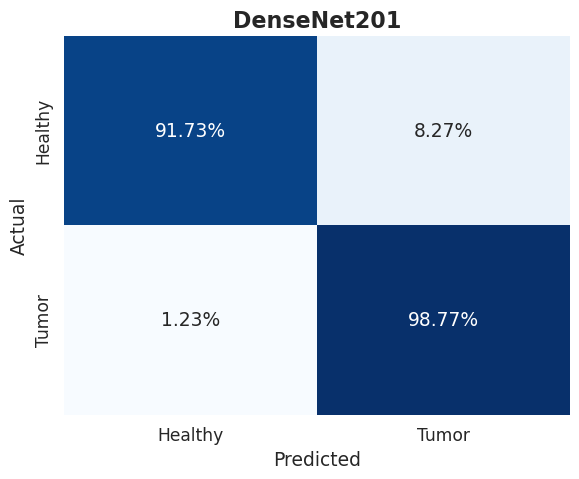

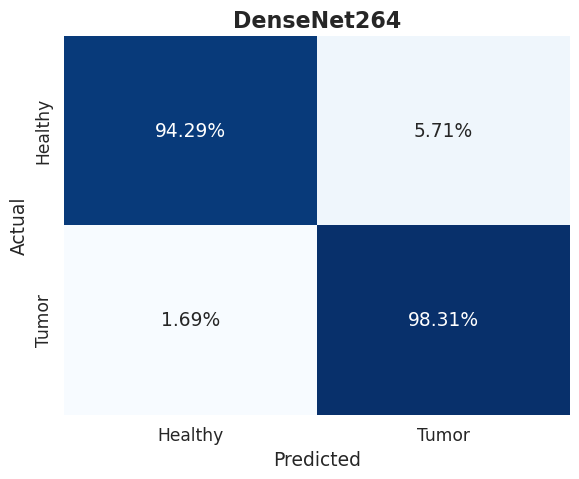

In [15]:
import seaborn as sns

for model_name in os.listdir(results_path):
    if "." in model_name:
        continue
    print()
    print(model_name)
    conf_matrices = []
    
    for fold in range(1, k_folds + 1):
        cm_path = os.path.join(results_path, model_name, f"fold-{fold}", "confusion_matrix.csv")
        cm = np.loadtxt(cm_path, delimiter=",", skiprows=1, usecols=(1,2))
        conf_matrices.append(cm)
    
    mean_cm = np.mean(conf_matrices, axis=0)

    # Normalize by row (true class)
    row_sums = mean_cm.sum(axis=1, keepdims=True)
    norm_cm = mean_cm / row_sums * 100

    # Plot
    plt.figure(figsize=(6, 5))
    annotations = np.array([[f"{val:.2f}%" for val in row] for row in norm_cm])
    sns.heatmap(norm_cm, annot=annotations, fmt="", cmap="Blues", 
                xticklabels=["Healthy", "Tumor"], yticklabels=["Healthy", "Tumor"], cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name}", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"images/{model_name}-normalized-mean-confusion-matrix.pdf", dpi=300)

In [16]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Optional: consistent FPR range for interpolation
fpr_grid = np.linspace(0, 1, 500)

all_model_rocs = {}

dir_2_models = {
    "DenseNet201": nets.densenet.DenseNet201,
    "DenseNet264": nets.densenet.DenseNet264,
    
}

for model_name in os.listdir(results_path):
    if "." in model_name:
        continue
    if "pre" in model_name:
        continue
    print(f"\nProcessing: {model_name}")
    
    tprs = []      # interpolated TPRs for each fold
    aucs = []      # AUCs for each fold
    target_specificity = 0.85
    target_fpr = 1 - target_specificity
    
    sensitivity_at_target = []
    for fold in range(1, k_folds + 1):
        chkpt_path = os.path.join(results_path, model_name, f"fold-{fold}", "best_metric_model.pth")
        if "Dense" in model_name:
            model = dir_2_models[model_name](spatial_dims=2, in_channels=1, out_channels=num_class).to(device)
        else:
            model = dir_2_models[model_name](spatial_dims=2, n_input_channels=1, num_classes=num_class).to(device)
        model.load_state_dict(torch.load(chkpt_path, weights_only=True))
        model.eval()

        y_true = []
        y_score = []  # ← prediction probabilities

        with torch.no_grad():
            for test_data in test_loader:
                test_images, test_labels = (
                    test_data[0].to(device),
                    test_data[1].to(device),
                )
                outputs = model(test_images)
                probs = torch.softmax(outputs, dim=1)[:, 1]  # Prob of class 'tumor'
                y_score.extend(probs.cpu().numpy())
                y_true.extend(test_labels.cpu().numpy())

        # Compute ROC
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

        interp_tpr = np.interp(target_fpr, fpr, tpr)
        sensitivity_at_target.append(interp_tpr)


        # Interpolate TPR for uniform FPR
        tpr_interp = np.interp(fpr_grid, fpr, tpr)
        tpr_interp[0] = 0.0  # Ensures ROC starts at (0, 0)
        tprs.append(tpr_interp)

    # Store model mean/std TPR and AUC
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    all_model_rocs[model_name] = {
        "fpr": fpr_grid,
        "mean_tpr": mean_tpr,
        "std_tpr": std_tpr,
        "mean_auc": mean_auc,
        "std_auc": std_auc,
    }
    sensitivity_mean = np.mean(sensitivity_at_target)
    sensitivity_std = np.std(sensitivity_at_target)
    
    print(f"{model_name} — Sensitivity at {target_specificity*100:.0f}% specificity: {sensitivity_mean:.3f} ± {sensitivity_std:.3f}")


Processing: DenseNet201
DenseNet201 — Sensitivity at 85% specificity: 0.995 ± 0.002

Processing: DenseNet264
DenseNet264 — Sensitivity at 85% specificity: 0.994 ± 0.006


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-28 13:17:37.505043: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-28 13:17:37.518047: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753701457.533744    3535 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753701457.538535    3535 cuda_blas.cc:1407] Unable to register 

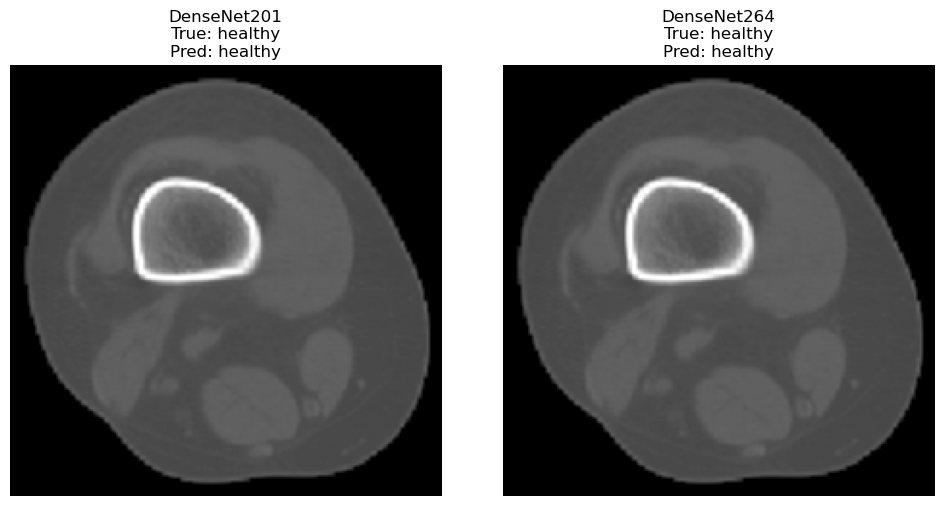

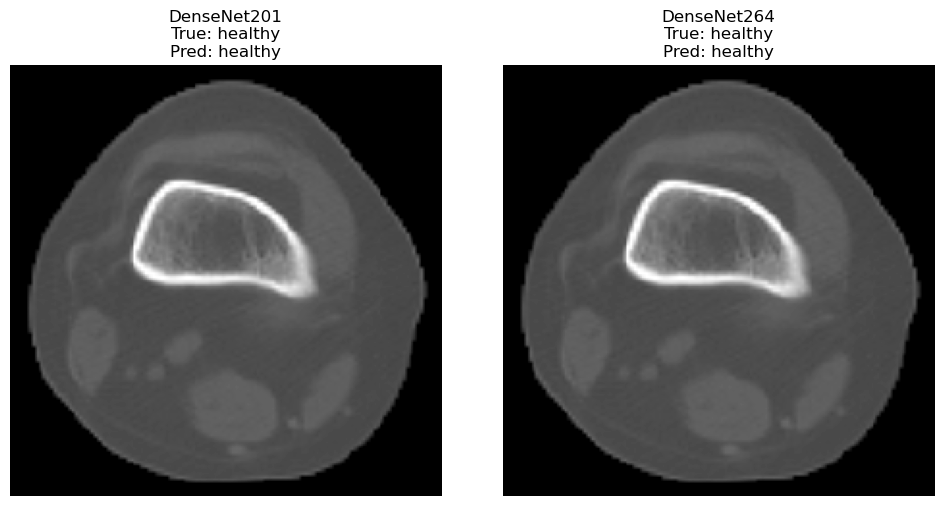

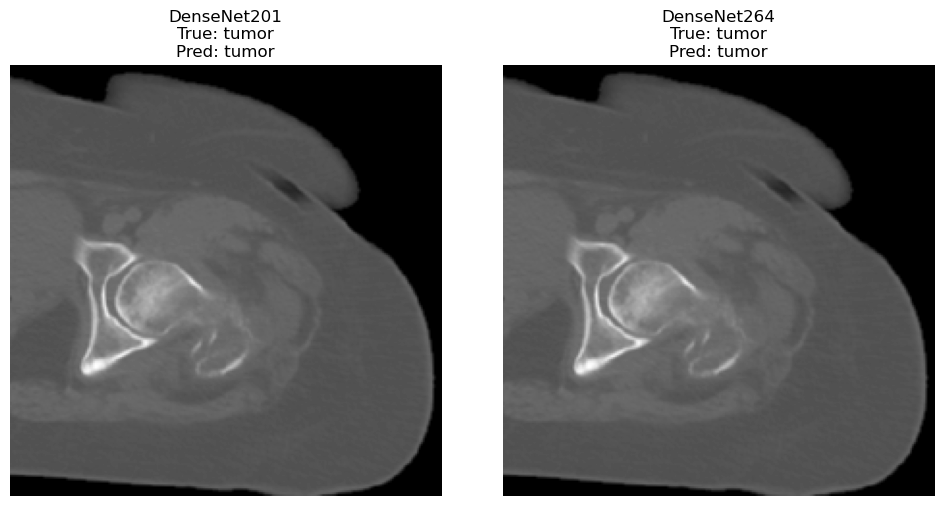

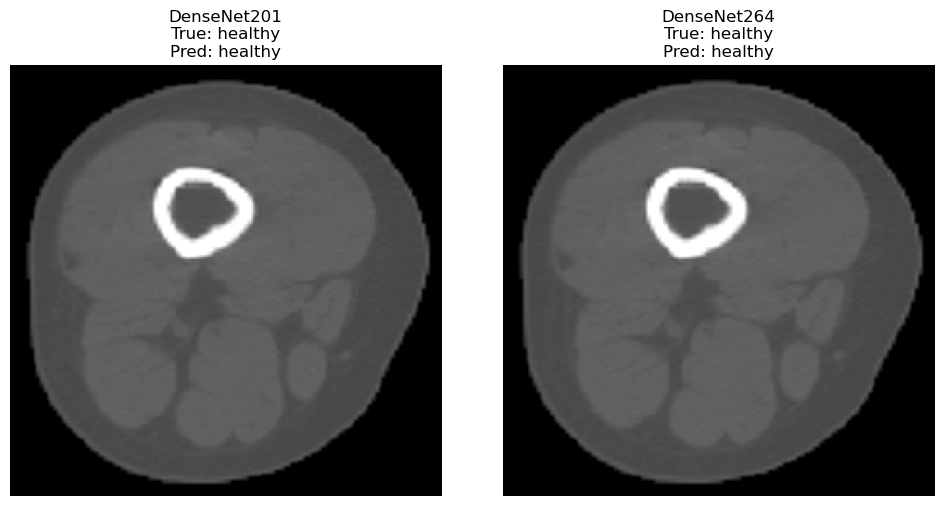

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from monai.networks.nets import DenseNet
from monai.transforms import Compose, ScaleIntensity, Resize, ToTensor

# --- Custom Dataset ---
class NPZDataset(Dataset):
    def __init__(self, files_list, label_map, transform=None):
        self.files_list = files_list
        self.label_map = label_map
        self.transform = transform

    def __len__(self):
        return len(self.files_list)

    def __getitem__(self, idx):
        npz_path = self.files_list[idx]
        data = np.load(npz_path)
        image = data['arr_0']

        label = self.label_map[npz_path.name]
        image = np.expand_dims(image, axis=0)  # Add channel dim

        if self.transform:
            image = self.transform(image)

        return image, label

# --- Visualization helper for side-by-side with model names ---
def imshow_side_by_side(img_tensor, true_label, pred1_label, pred2_label, class_names, model_names):
    img = img_tensor.squeeze().cpu().numpy()
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    preds = [pred1_label, pred2_label]

    for i in range(2):
        axs[i].imshow(img, cmap='gray')
        axs[i].set_title(
            f"{model_names[i]}\nTrue: {class_names[true_label]}\nPred: {class_names[preds[i]]}",
            fontsize=12
        )
        axs[i].axis('off')

    plt.tight_layout()
    plt.show()

# --- Setup ---
data_path = Path("/home/ashah/data-2025-04-21-not-processed")
files_list = list(data_path.glob("*.npz"))
class_names = ["healthy", "tumor"]

label_map = {}
for f in files_list:
    name = f.name.lower()
    if "healthy" in name:
        label_map[f.name] = 0
    elif "tumor" in name:
        label_map[f.name] = 1
    else:
        raise ValueError(f"File {f.name} has no class keyword.")

transform = Compose([
    ScaleIntensity(),
    Resize((224, 224)),
    ToTensor()
])

dataset = NPZDataset(files_list, label_map, transform=transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=False)

def load_model(model_path, block_config):
    model = DenseNet(
        spatial_dims=2,
        in_channels=1,
        out_channels=2,
        init_features=64,
        growth_rate=32,
        block_config=block_config
    )
    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.eval()
    return model

model1 = load_model(
    "results/2025-07-21/DenseNet201/fold-6/best_metric_model.pth",
    block_config=(6, 12, 48, 32)  # DenseNet201
)

model2 = load_model(
    "results/2025-07-21/DenseNet264/fold-3/best_metric_model.pth",
    block_config=(6, 12, 64, 48)  # DenseNet264
)

model_names = ["DenseNet201", "DenseNet264"]

# --- Inference and side-by-side display ---
with torch.no_grad():
    for images, labels in dataloader:
        outputs1 = model1(images)
        outputs2 = model2(images)

        _, preds1 = torch.max(outputs1, 1)
        _, preds2 = torch.max(outputs2, 1)

        for i in range(images.size(0)):
            imshow_side_by_side(
                images[i], labels[i].item(), preds1[i].item(), preds2[i].item(), class_names, model_names
            )
        break  # remove break to run on full dataset

